🏷️ District: ناحیه 14 هکتاری
🎯 Centroid: [52.527728, 29.78933]
📍 Boundary points: 49


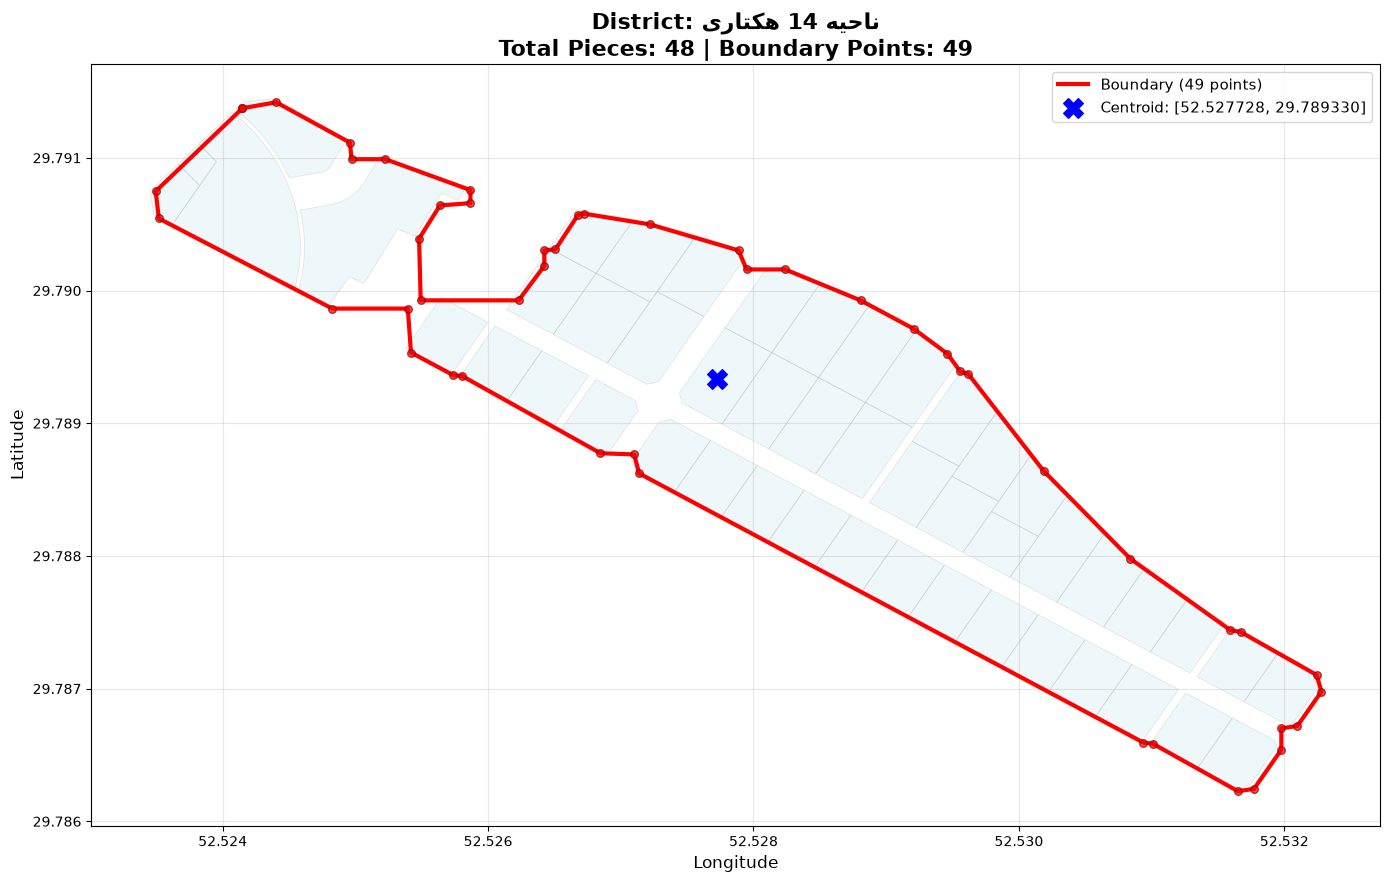

In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

# ============================================================
# Load GeoJSON file
# ============================================================
geojson_path = "14hectari.geojson"  # ← Change this

with open(geojson_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

district_name = data.get('name', 'Unknown')
centroid = data.get('centroid', [0, 0])
boundary = data.get('boundary', [])

print(f"🏷️ District: {district_name}")
print(f"🎯 Centroid: {centroid}")
print(f"📍 Boundary points: {len(boundary)}")

# ============================================================
# Extract polygons for background
# ============================================================
polygons = []
for feature in data.get('features', []):
    geom = feature.get('geometry')
    if geom.get('type') == 'Polygon':
        polygons.append(Polygon(geom['coordinates'][0]))
    elif geom.get('type') == 'MultiPolygon':
        for coords in geom['coordinates']:
            polygons.append(Polygon(coords[0]))

# ============================================================
# Create figure
# ============================================================
fig, ax = plt.subplots(figsize=(14, 12))

# ============================================================
# Draw all pieces (light background)
# ============================================================
for poly in polygons:
    if poly.geom_type == 'Polygon':
        x, y = poly.exterior.xy
        ax.fill(x, y, alpha=0.2, color='lightblue', edgecolor='gray', linewidth=0.5)

# ============================================================
# Draw boundary (red line)
# ============================================================
if boundary:
    b_x = [p[0] for p in boundary]
    b_y = [p[1] for p in boundary]
    
    # Draw boundary line
    ax.plot(b_x, b_y, 'r-', linewidth=3, label=f'Boundary ({len(boundary)} points)')
    
    # Draw boundary points
    ax.scatter(b_x, b_y, c='red', s=30, zorder=5, alpha=0.7, edgecolors='darkred', linewidth=1)

# ============================================================
# Draw centroid
# ============================================================
if centroid:
    ax.scatter(centroid[0], centroid[1], 
              c='blue', s=200, marker='X', zorder=10,
              label=f'Centroid: [{centroid[0]:.6f}, {centroid[1]:.6f}]')

# ============================================================
# Labels and title
# ============================================================
ax.set_title(f"District: {district_name}\nTotal Pieces: {len(polygons)} | Boundary Points: {len(boundary)}", 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()